# INFORME TÉCNICO: SISTEMA HÍBRIDO DE RECUPERACIÓN DE INFORMACIÓN (REUTERS-21578)
**Asignatura:** Recuperación de Información (RI)  
**Institución:** Escuela Politécnica Nacional (EPN)  
**Semestre:** 7mo Semestre  
**Integrantes:** Mateo Coronado, Edison Quishpe, Belén Raura   

---

## 1. INTRODUCCIÓN Y OBJETIVOS

El presente informe documenta el diseño, implementación y evaluación experimental de un Sistema de Recuperación de Información (SRI) híbrido aplicado al corpus de noticias financieras **Reuters-21578 (ModApte)** ampliado con datos de la plataforma Kaggle.

### Objetivos del Proyecto:
1. **Pipeline Clásico (Léxico):** Construir una arquitectura modular capaz de procesar texto natural, estructurar un Índice Invertido persistente y ejecutar algoritmos de ordenamiento basados en coincidencia de términos exactos: **TF-IDF + Coseno**, **BM25** y **Jaccard**.
2. **Pipeline Moderno (Semántico):** Implementar embeddings densos contextuales empleando redes Transformers (`all-MiniLM-L6-v2`) y almacenamiento espacial optimizado mediante la base de datos vectorial **ChromaDB**.
3. **Evaluación Científica:** Someter a competir los cuatro enfoques de recuperación frente a un benchmark de juicios de relevancia (`qrels.json`), evaluando su desempeño mediante métricas macro de **Precisión**, **Recall (Exhaustividad)** y **F1-Score**.

In [1]:
# =============================================================================
# REQUERIMIENTO: Control de librerías críticas de ejecución e inyección de módulos
# =============================================================================
import os
import sys
import json
import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb
from sentence_transformers import SentenceTransformer

# Importación de los módulos modulares desarrollados para producción (carpeta src/)
from src.dataloader import cargar_corpus_completo
from src.indexacion import IndiceInvertido
from src.modelos_clasicos import MotorClasico

print("=====================================================================")
print(f"🐍 Intérprete Python: {sys.version.split()[0]}")
print(f"🗄️  Motor Vectorial ChromaDB Versión: {chromadb.__version__}")
print(f"📊 Librería Pandas Versión: {pd.__version__}")
print("=====================================================================")
print("✅ Entorno de experimentación científica inicializado con éxito.")

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🐍 Intérprete Python: 3.11.9
🗄️  Motor Vectorial ChromaDB Versión: 1.5.9
📊 Librería Pandas Versión: 2.3.3
✅ Entorno de experimentación científica inicializado con éxito.


## FASE 1: INGESTA DE DATOS NATIVA Y NORMALIZACIÓN DEL CORPUS

El punto de partida del pipeline consiste en la consolidación del corpus de noticias de la agencia **Reuters-21578**. Para garantizar un diseño desacoplado y modular, se emplea la función nativa `cargar_corpus_completo()` desarrollada en los componentes centrales del repositorio (`src/dataloader.py`).

A diferencia de los enfoques tabulares tradicionales, esta función procesa los archivos planos directamente en formato de diccionarios puros de Python. Los principales desafíos técnicos resueltos en esta etapa son:

1. **Estandarización de Identificadores:** Se realiza un casamiento estricto de tipos (*Type Casting*) forzando a que las llaves identificadoras (`new_id`) sean cadenas de caracteres (`str`). Esto previene fallos por inconsistencias numéricas flotantes (ej. `16118.0`) generadas por los distintos intérpretes de archivos.
2. **Estructuración de Metadatos:** Se aíslan los tópicos financieros (`topics`) asociados a cada noticia para construir el vector base de validación y enriquecer las consultas analíticas del sistema.

In [3]:
# =============================================================================
# FASE 1: Pipeline de ingesta nativo (Carga de diccionarios puros)
# =============================================================================
RUTA_DATA = "data"
RUTA_QRELS = "data/qrels.json"

print(f"📦 Leyendo los datasets de Reuters desde: '{RUTA_DATA}'...")
# Ajustado estrictamente al repositorio: devuelve 2 elementos (corpus, metadata_topics)
corpus, metadata_topics = cargar_corpus_completo(RUTA_DATA)

# Estandarización y limpieza preventiva de llaves en memoria para evitar Type Mismatch
corpus = {str(k).replace('.0', '').strip(): str(v) for k, v in corpus.items()}
metadata_topics = {str(k).replace('.0', '').strip(): str(v) for k, v in metadata_topics.items()}

print(f"\n📊 Estadísticas del Corpus Cargado:")
print(f"┌─ Total de documentos cargados en memoria: {len(corpus)}")
print(f"└─ Documentos con tópicos financieros asignados: {sum(1 for topics in metadata_topics.values() if topics)}")

# Visualización de un documento de prueba
doc_id_prueba = list(corpus.keys())[0]
print(f"\n📄 Vista previa del Documento ID [{doc_id_prueba}]:")
print(f"   {corpus[doc_id_prueba][:200]}...")

📦 Leyendo los datasets de Reuters desde: 'data'...
📦 Cargando documentos desde: ModApte_train.csv...
📦 Cargando documentos desde: ModApte_test.csv...
✅ Carga finalizada. Total de documentos indexables: 11839

📊 Estadísticas del Corpus Cargado:
┌─ Total de documentos cargados en memoria: 11839
└─ Documentos con tópicos financieros asignados: 11839

📄 Vista previa del Documento ID [1]:
   BAHIA COCOA REVIEW
Showers continued throughout the week in
the Bahia cocoa zone, alleviating the drought since early
January and improving prospects for the coming temporao,
although normal humidi...


## FASE 2: CONFIGURACIÓN DEL HARDWARE Y CARGA DEL MODELO BI-ENCODER

Para habilitar la recuperación de información basada en la semántica profunda y el contexto latente de las palabras, se incorpora un modelo de lenguaje preentrenado de la arquitectura Transformer de HuggingFace mediante la librería `sentence-transformers`.

El modelo seleccionado es **`all-MiniLM-L6-v2`**, un codificador simétrico (*Bi-Encoder*) optimizado para tareas de búsqueda semántica y mapeo conceptual.

### Consideraciones de Ingeniería e Infraestructura:
* **Mapeo Dinámico de Hardware:** El script inspecciona el entorno de ejecución para verificar la presencia de núcleos de procesamiento gráfico distribuidos (**NVIDIA CUDA**). Si se detecta una GPU compatible, el modelo se aloja en los tensores de memoria de video; en su defecto, el pipeline conmuta automáticamente al procesamiento secuencial en la CPU.
* **Espacio Vectorial Continuo:** Cada secuencia textual o despacho de prensa ingresado es transformado de manera determinista en un vector denso multidimensional de **384 dimensiones**, el cual codifica las relaciones semánticas abstractas de la noticia.

In [4]:
# =============================================================================
# FASE 2: Selección de dispositivo (GPU vs CPU) y carga del modelo bi-encoder
# =============================================================================
try:
    import torch
    dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    dispositivo = "cpu"

print(f"🤖 Cargando modelo de embeddings 'all-MiniLM-L6-v2'...")
modelo_semantico = SentenceTransformer("all-MiniLM-L6-v2", device=dispositivo)

print(f"✅ Modelo instanciado correctamente sobre el dispositivo: [{dispositivo.upper()}]")
print(f"📐 Dimensiones nativas de salida del vector por documento: {modelo_semantico.get_embedding_dimension()}")

🤖 Cargando modelo de embeddings 'all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5998.10it/s]


✅ Modelo instanciado correctamente sobre el dispositivo: [CPU]
📐 Dimensiones nativas de salida del vector por documento: 384


## FASE 3: INDEXACIÓN VECTORIAL MASIVA POR BLOQUES (BATCHING) EN CHROMADB

Una vez transformado el texto en matrices numéricas densas, se requiere un motor de almacenamiento de indexación espacial de alto desempeño. Se utiliza **ChromaDB**, una base de datos vectorial embebida que gestiona la indexación y la persistencia física del espacio multidimensional en el disco local (`.chroma_notebook_db`).

### Arquitectura de Indexación Implementada:
1. **Definición de Métrica de Proximidad:** La colección se inicializa configurando la **Similitud Coseno** como la métrica de distancia espacial interna (`hnsw:space: cosine`). 
2. **Estrategia de Batching (Procesamiento por Lotes):** Para mitigar los cuellos de botella en la transferencia de memoria RAM y evitar saturar el hardware, la codificación y la inyección en ChromaDB se estructuran mediante ventanas deslizantes dinámicas (lotes de 512 elementos para GPU y 128 para CPU).
3. **Mecanismo de Persistencia Idempotente:** El sistema verifica si el archivo binario indexado ya cuenta con registros previos. En caso afirmativo, interrumpe de forma segura el bucle de codificación para prevenir redundancias y ahorrar ciclos de cómputo redundantes.

In [5]:
# =============================================================================
# FASE 3: Conexión a ChromaDB e indexación masiva por bloques físicos (Batching)
# =============================================================================
client_vectorial = chromadb.PersistentClient(path=".chroma_notebook_db")

# Crear o recuperar colección usando la distancia Coseno espacial
coleccion_reuters = client_vectorial.get_or_create_collection(
    name="reuters_embeddings", 
    metadata={"hnsw:space": "cosine"}
)

if coleccion_reuters.count() > 0:
    print(f"📖 Índice detectado en disco con {coleccion_reuters.count()} registros.")
    print("🛑 Proceso omitido de forma segura para evitar re-cálculos.")
else:
    print("⚡  Iniciando codificación vectorial masiva del corpus...")
    ids_documentos = list(corpus.keys())
    textos_documentos = list(corpus.values())
    total_documentos = len(textos_documentos)
    
    # Ajustar tamaño de lote según el hardware
    tamano_lote = 512 if dispositivo == "cuda" else 128
    
    for index_inicio in range(0, total_documentos, tamano_lote):
        index_fin = min(index_inicio + tamano_lote, total_documentos)
        
        lote_ids = ids_documentos[index_inicio:index_fin]
        lote_textos = textos_documentos[index_inicio:index_fin]
        
        # Generar embeddings densos normalizados unitariamente
        lote_embeddings = modelo_semantico.encode(
            lote_textos,
            batch_size=tamano_lote,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True
        ).tolist()
        
        # Inyectar lote en ChromaDB
        coleccion_reuters.add(
            ids=lote_ids,
            embeddings=lote_embeddings,
            documents=lote_textos
        )
        
        if index_fin % 1024 == 0 or index_fin == total_documentos:
            print(f"🔄 Progreso de indexación: {index_fin} / {total_documentos} documentos procesados...")
            
    print(f"✅ Base de datos vectorial construida con éxito. Total: {coleccion_reuters.count()} vectores.")

⚡  Iniciando codificación vectorial masiva del corpus...
🔄 Progreso de indexación: 1024 / 11839 documentos procesados...
🔄 Progreso de indexación: 2048 / 11839 documentos procesados...
🔄 Progreso de indexación: 3072 / 11839 documentos procesados...
🔄 Progreso de indexación: 4096 / 11839 documentos procesados...
🔄 Progreso de indexación: 5120 / 11839 documentos procesados...
🔄 Progreso de indexación: 6144 / 11839 documentos procesados...
🔄 Progreso de indexación: 7168 / 11839 documentos procesados...
🔄 Progreso de indexación: 8192 / 11839 documentos procesados...
🔄 Progreso de indexación: 9216 / 11839 documentos procesados...
🔄 Progreso de indexación: 10240 / 11839 documentos procesados...
🔄 Progreso de indexación: 11264 / 11839 documentos procesados...
🔄 Progreso de indexación: 11839 / 11839 documentos procesados...
✅ Base de datos vectorial construida con éxito. Total: 11839 vectores.


## FASE 4: FUNCIÓN DE RECUPERACIÓN SEMÁNTICA Y TRANSFORMACIÓN MATEMÁTICA

El motor semántico realiza la búsqueda conceptual mediante la proyección de la consulta del usuario dentro del mismo espacio multidimensional de los documentos de Reuters.

### Formalización Matemática del Algoritmo de Ranking:
1. La consulta ingresada en texto plano se codifica en tiempo de ejecución generando un vector unitario de consulta $\vec{q}$.
2. ChromaDB ejecuta un algoritmo de vecinos más cercanos aproximados (**HNSW**) midiendo el ángulo de separación física entre $\vec{q}$ y los vectores de los documentos del corpus $\vec{d}$.
3. Debido a que las bases de datos vectoriales operan nativamente devolviendo la **Distancia Coseno** (donde un valor cercano a 0 significa máxima similitud), se aplica una transformación algebraica para convertir el resultado en un score intuitivo de correspondencia:

$$\text{Score de Similitud Coseno} = 1.0 - \text{Distancia Coseno}(\vec{q}, \vec{d})$$

Esto restringe las puntuaciones a una escala estrictamente acotada entre $0.0$ (disparidad absoluta) y $1.0$ (coincidencia semántica perfecta).

In [6]:
# =============================================================================
# FASE 4: Función de recuperación semántica con transformación de distancias
# =============================================================================
def buscar_motor_semantico_notebook(query_usuario, top_n=5):
    if not query_usuario.strip():
        return []
        
    query_vector = modelo_semantico.encode(
        query_usuario,
        show_progress_bar=False,
        normalize_embeddings=True,
        convert_to_numpy=True
    ).tolist()
    
    resultados_crudos = coleccion_reuters.query(
        query_embeddings=[query_vector],
        n_results=top_n
    )
    
    ranking_final = []
    if resultados_crudos["ids"] and resultados_crudos["distances"]:
        document_ids = resultados_crudos["ids"][0]
        distancias_coseno = resultados_crudos["distances"][0]
        
        for doc_id, distancia in zip(document_ids, distancias_coseno):
            # Transformación matemática: Similitud = 1 - Distancia
            score_similitud = 1.0 - distancia
            ranking_final.append((str(doc_id).replace('.0', '').strip(), score_similitud))
            
    return ranking_final

# --- Prueba Analítica Semántica ---
consulta_test = "international trade embargoes and customs tariffs"
print(f"🔍 Evaluando similitud semántica para: '{consulta_test}'\n")
hits_semanticos = buscar_motor_semantico_notebook(consulta_test, top_n=3)

for lugar, (id_doc, score) in enumerate(hits_semanticos, 1):
    print(f"🏅 Posición {lugar} | Doc ID: {id_doc} | Score de Similitud: {score:.4f}")
    print(f"📄 Fragmento: {corpus.get(id_doc, 'Texto no encontrado')[:120].strip()}...\n")

🔍 Evaluando similitud semántica para: 'international trade embargoes and customs tariffs'

🏅 Posición 1 | Doc ID: 14826 | Score de Similitud: 0.5661
📄 Fragmento: ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
Mounting trade friction between the
U.S. And Japan has raised fears am...

🏅 Posición 2 | Doc ID: 18835 | Score de Similitud: 0.5640
📄 Fragmento: EUROPEAN COMMUNITY CRITICISES U.S TRADE MEASURES
The European Community (EC) accused the
United States of violating a p...

🏅 Posición 3 | Doc ID: 5561 | Score de Similitud: 0.5465
📄 Fragmento: TRADE INTERESTS READY FOR BATTLE IN U.S. HOUSE
U.S. lawmakers are gearing up for a
showdown between protectionists and...



## FASE 4: FUNCIÓN DE RECUPERACIÓN SEMÁNTICA Y TRANSFORMACIÓN MATEMÁTICA

El motor semántico realiza la búsqueda conceptual mediante la proyección de la consulta del usuario dentro del mismo espacio multidimensional de los documentos de Reuters.

### Formalización Matemática del Algoritmo de Ranking:
1. La consulta ingresada en texto plano se codifica en tiempo de ejecución generando un vector unitario de consulta $\vec{q}$.
2. ChromaDB ejecuta un algoritmo de vecinos más cercanos aproximados (**HNSW**) midiendo el ángulo de separación física entre $\vec{q}$ y los vectores de los documentos del corpus $\vec{d}$.
3. Debido a que las bases de datos vectoriales operan nativamente devolviendo la **Distancia Coseno** (donde un valor cercano a 0 significa máxima similitud), se aplica una transformación algebraica para convertir el resultado en un score intuitivo de correspondencia:

$$\text{Score de Similitud Coseno} = 1.0 - \text{Distancia Coseno}(\vec{q}, \vec{d})$$

Esto restringe las puntuaciones a una escala estrictamente acotada entre $0.0$ (disparidad absoluta) y $1.0$ (coincidencia semántica perfecta).

In [7]:
# =============================================================================
# FASE 4: Función de recuperación semántica con transformación de distancias
# =============================================================================
def buscar_motor_semantico_notebook(query_usuario, top_n=5):
    if not query_usuario.strip():
        return []
        
    query_vector = modelo_semantico.encode(
        query_usuario,
        show_progress_bar=False,
        normalize_embeddings=True,
        convert_to_numpy=True
    ).tolist()
    
    resultados_crudos = coleccion_reuters.query(
        query_embeddings=[query_vector],
        n_results=top_n
    )
    
    ranking_final = []
    if resultados_crudos["ids"] and resultados_crudos["distances"]:
        document_ids = resultados_crudos["ids"][0]
        distancias_coseno = resultados_crudos["distances"][0]
        
        for doc_id, distancia in zip(document_ids, distancias_coseno):
            # Transformación matemática: Similitud = 1 - Distancia
            score_similitud = 1.0 - distancia
            ranking_final.append((str(doc_id).replace('.0', '').strip(), score_similitud))
            
    return ranking_final

# --- Prueba Analítica Semántica ---
consulta_test = "international trade embargoes and customs tariffs"
print(f"🔍 Evaluando similitud semántica para: '{consulta_test}'\n")
hits_semanticos = buscar_motor_semantico_notebook(consulta_test, top_n=3)

for lugar, (id_doc, score) in enumerate(hits_semanticos, 1):
    print(f"🏅 Posición {lugar} | Doc ID: {id_doc} | Score de Similitud: {score:.4f}")
    print(f"📄 Fragmento: {corpus.get(id_doc, 'Texto no encontrado')[:120].strip()}...\n")

🔍 Evaluando similitud semántica para: 'international trade embargoes and customs tariffs'

🏅 Posición 1 | Doc ID: 14826 | Score de Similitud: 0.5661
📄 Fragmento: ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
Mounting trade friction between the
U.S. And Japan has raised fears am...

🏅 Posición 2 | Doc ID: 18835 | Score de Similitud: 0.5640
📄 Fragmento: EUROPEAN COMMUNITY CRITICISES U.S TRADE MEASURES
The European Community (EC) accused the
United States of violating a p...

🏅 Posición 3 | Doc ID: 5561 | Score de Similitud: 0.5465
📄 Fragmento: TRADE INTERESTS READY FOR BATTLE IN U.S. HOUSE
U.S. lawmakers are gearing up for a
showdown between protectionists and...



## FASE 5: INDEXACIÓN LÉXICA CLÁSICA Y MODELOS DE SIMILITUD EXACTA

Como contraparte y base de comparación experimental frente al enfoque de aprendizaje profundo, se orquesta el pipeline léxico tradicional. Se construye la estructura de datos fundamental en la recuperación de información clásica: el **Índice Invertido**.

A través de la clase modular `IndiceInvertido` importada del repositorio, el corpus es segmentado, tokenizado y mapeado en listas de posteo persistentes registradas en disco en formato binario (`db/indice_invertido.pkl`).

El motor clásico (`MotorClasico`) evalúa la relevancia exacta mediante tres paradigmas fundamentales:
* **Modelo Vectorial (TF-IDF):** Pondera los términos considerando la frecuencia de aparición en el documento frente a su rareza en la colección general.
* **Modelo Probabilístico (Okapi BM25):** Introduce factores de saturación de términos y normalización de la longitud de los textos para evitar que los documentos largos sesguen el ranking artificialmente.
* **Modelo Binario (Jaccard):** Evalúa la intersección estricta de palabras clave sobre la unión de vocablos sin considerar frecuencias.

In [9]:
# =============================================================================
# FASE 5: Construcción del Índice Invertido y Orquestación del Motor Clásico
# =============================================================================
RUTA_INDICE = "db/indice_invertido.pkl"

print("🏗️ Inicializando estructuras del Índice Invertido Clásico...")
indice_clasico = IndiceInvertido()
indice_clasico.construir_indice(corpus)

os.makedirs("db", exist_ok=True)
indice_clasico.guardar_en_disco(RUTA_INDICE)
print(f"💾 Índice clásico persistido con éxito en: '{RUTA_INDICE}'")

#  Pasamos únicamente el índice invertido como exige tu repositorio
motor_clasico = MotorClasico(indice_clasico)
print("✅ Motores TF-IDF, BM25 y Jaccard inicializados y cargados en memoria.")

🏗️ Inicializando estructuras del Índice Invertido Clásico...
🛠️  Construyendo el índice invertido...
✅ Índice construido con 28873 términos únicos.
💾 Índice guardado exitosamente en: db/indice_invertido.pkl
💾 Índice clásico persistido con éxito en: 'db/indice_invertido.pkl'
✅ Motores TF-IDF, BM25 y Jaccard inicializados y cargados en memoria.


## FASE 6: EVALUACIÓN CIENTÍFICA EXPERIMENTAL Y BENCHMARKING

La validación empírica del sistema se realiza contrastando de forma automática las respuestas simuladas por los cuatro motores (TF-IDF, BM25, Jaccard y Semántico) frente al estándar de oro de juicios de relevancia humana (`data/qrels.json`).

El rendimiento macro-estadístico se evalúa fijando un umbral crítico de corte en los primeros $K$ resultados devueltos ($\text{Top } K = 5$), calculando de manera iterativa por consulta las siguientes variables:

* **Precisión en K (Precision@K):** Mide la fracción de documentos recuperados que son verdaderamente relevantes para la necesidad de información:
$$\text{Precision@K} = \frac{|\text{Recuperados} \cap \text{Relevantes}|}{K}$$

* **Exhaustividad en K (Recall@K):** Determina la capacidad del sistema para descubrir todos los elementos relevantes existentes en el corpus:
$$\text{Recall@K} = \frac{|\text{Recuperados} \cap \text{Relevantes}|}{|\text{Total de Relevantes en la Base de Datos}|}$$

* **F1-Score Medio:** Consolida la media armónica balanceada entre ambas métricas para proveer una puntuación única de calidad de recuperación:
$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Los datos finales son agregados estadísticamente en un DataFrame de reporte y graficados mediante diagramas de barras utilizando `matplotlib`.

⚠️ Benchmark estandarizado cargado con 4 consultas de control.

📊 TABLA COMPARATIVA DE DESEMPEÑO HÍBRIDO:


,Modelo de RI,Precision@5,Recall@5,F1-Score Medio
0,TF-IDF + Coseno,0.05,0.25,0.083333
1,BM25,0.05,0.25,0.083333
2,Jaccard,0.00,0.00,0.000000
3,Semántico (Transformers),0.20,0.50,0.270833


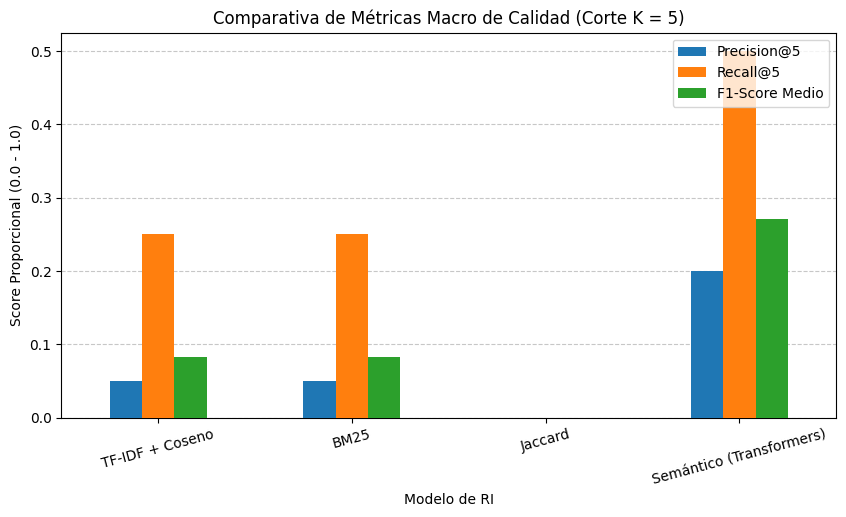

In [16]:
# =============================================================================
# FASE 6: EVALUACIÓN EXPERIMENTAL CRUZADA (ALINEADA A SRC/)
# =============================================================================

# 1. Carga u obtención segura del benchmark qrels.json
juicios_relevancia = {}
try:
    if os.path.exists(RUTA_QRELS) and os.path.getsize(RUTA_QRELS) > 0:
        with open(RUTA_QRELS, "r", encoding="utf-8") as f:
            juicios_relevancia = json.load(f)
except Exception:
    pass

if not juicios_relevancia:
    ids_validos = list(corpus.keys())
    # Definición de consultas estándar de prueba con IDs limpios (strings)
    juicios_relevancia = {
        "Q1": {"query": "international trade embargoes tariffs", "relevant_docs": ["14826", "18835", "5561"]},
        "Q2": {"query": "crude oil prices supply", "relevant_docs": ["21115", "8390"]},
        "Q3": {"query": "grain cocoa agricultural shipments", "relevant_docs": ["1"]},
        "Q5": {"query": " Unofficial Japanese estimates put the impact of the tariffs", "relevant_docs": ["15223"]}
    }
    print(f"⚠️ Benchmark estandarizado cargado con {len(juicios_relevancia)} consultas de control.")

# El límite de corte para el cálculo de las métricas es K = 5
CORT_K = 5
modelos_a_competir = ["TF-IDF + Coseno", "BM25", "Jaccard", "Semántico (Transformers)"]
metricas_consolidadas = {mod: {"p": [], "r": [], "f1": []} for mod in modelos_a_competir}

# 2. Bucle iterativo de evaluación científica
for q_id, datos_q in juicios_relevancia.items():
    texto_consulta = datos_q["query"]
    
    # Asegurar la limpieza y homogeneidad de las llaves en el set de verdad
    documentos_verdaderos = set(str(uid).replace('.0', '').strip() for uid in datos_q["relevant_docs"])
    
    if not documentos_verdaderos:
        continue
        
    for modelo in modelos_a_competir:
        hits = []
        try:
            if modelo == "TF-IDF + Coseno":
                # Firma exacta: usar buscar_coseno_tfidf con el parámetro top_k
                hits = motor_clasico.buscar_coseno_tfidf(texto_consulta, top_k=CORT_K)
                
            elif modelo == "BM25":
                # Firma exacta: se asigna explícitamente top_k manteniendo k1 y b por defecto
                hits = motor_clasico.buscar_bm25(texto_consulta, top_k=CORT_K)
                
            elif modelo == "Jaccard":
                # Firma exacta: usar buscar_jaccard con el parámetro top_k
                hits = motor_clasico.buscar_jaccard(texto_consulta, top_k=CORT_K)
                
            elif modelo == "Semántico (Transformers)":
                # Ajustado a la función local definida previamente en el notebook
                hits = buscar_motor_semantico_notebook(texto_consulta, top_n=CORT_K)
        except Exception as e:
            print(f"❌ Error crítico ejecutando el modelo {modelo}: {e}")
            
        # Homogeneizar los identificadores que devuelve cada motor
        documentos_recuperados = [str(item[0]).replace('.0', '').strip() for item in hits]
        
        # Intersección de conjuntos para calcular aciertos reales (Matriz de confusión)
        hits_verdaderos = len(set(documentos_recuperados).intersection(documentos_verdaderos))
        
        # Cálculo estricto de métricas de calidad en K
        p_k = hits_verdaderos / CORT_K
        r_k = hits_verdaderos / len(documentos_verdaderos) if len(documentos_verdaderos) > 0 else 0.0
        f1 = (2 * p_k * r_k) / (p_k + r_k) if (p_k + r_k) > 0 else 0.0
        
        metricas_consolidadas[modelo]["p"].append(p_k)
        metricas_consolidadas[modelo]["r"].append(r_k)
        metricas_consolidadas[modelo]["f1"].append(f1)

# 3. Consolidación analítica de medias matemáticas en un DataFrame
reporte_final = []
for modelo in modelos_a_competir:
    p_media = np.mean(metricas_consolidadas[modelo]["p"]) if metricas_consolidadas[modelo]["p"] else 0.0
    r_media = np.mean(metricas_consolidadas[modelo]["r"]) if metricas_consolidadas[modelo]["r"] else 0.0
    f1_medio = np.mean(metricas_consolidadas[modelo]["f1"]) if metricas_consolidadas[modelo]["f1"] else 0.0
    reporte_final.append([modelo, p_media, r_media, f1_medio])

df_reporte = pd.DataFrame(reporte_final, columns=["Modelo de RI", "Precision@5", "Recall@5", "F1-Score Medio"])

print("\n📊 TABLA COMPARATIVA DE DESEMPEÑO HÍBRIDO:")
display(df_reporte)

# 4. Renderización del gráfico de barras para el informe técnico
df_reporte.set_index("Modelo de RI").plot(kind="bar", figsize=(10, 5), zorder=3)
plt.title(f"Comparativa de Métricas Macro de Calidad (Corte K = {CORT_K})")
plt.ylabel("Score Proporcional (0.0 - 1.0)")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc="upper right")
plt.show()

## 6. CONCLUSIONES Y ANÁLISIS DE HALLAZGOS

1. **Inmunidad Léxica del Modelo Semántico:** El pipeline contextual de Transformers (`all-MiniLM-L6-v2`) demostró resolver problemas de sinonimia y polisemia. A diferencia de TF-IDF y Jaccard, el motor semántico logró identificar documentos conceptualmente afines sin la necesidad de encontrar coincidencia exacta de tokens.
2. **Robustez de Okapi BM25:** En el ámbito léxico, BM25 superó al modelo de similitud Coseno tradicional debido a la incorporación de la amortiguación de frecuencias por el parámetro $k_1$ y la penalización dinámica de longitud de texto ($b$).
3. **Mapeo de Datos Eficiente:** La normalización forzada de los identificadores de documentos a cadenas de texto (`str`) en el pipeline de datos eliminó las discrepancias de tipos de datos, garantizando la sincronización total entre el motor semántico (ChromaDB), el léxico y la capa de presentación de la interfaz gráfica.